# はじめに
本レポートは、半年間受講したデータサイエンスコースの学習成果を実践的に確認することを目的とした練習課題である。特に、時系列データの構造を理解するための分解手法と、将来予測モデルの構築を、実際のオープンデータを用いて行うことに重点を置いている。
分析対象として岡山市を選定した理由は、地方中核都市として一定の都市機能を持ちながらも、エリアごとに役割や人の集まり方が明確に異なる点に分析価値を感じたためである。駅前や商業拠点、住宅地など性格の異なる地域が比較的コンパクトな範囲に集まっており、人流データを通じて地域特性の違いを捉えやすいと考えた。また、人流データそのものに強い関心があり、都市部における人の動きが時間とともにどのように変化するのかを、定量的に可視化・予測してみたいと考えた。本分析では、岡山市の都心部周辺に絞って各エリアの人流の傾向を比較し、時系列的な特徴を明らかにすることを目指す。


# 分析するデータ
## 用いたデータについて
本分析では、岡山市が公式に公開している人流データのオープンデータを使用した。データは岡山市公式ウェブサイトよりCSV形式で取得し、公開されているデータ定義および留意事項を確認した上で利用している。

## データ定義・留意点
* データは携帯端末の位置情報等をもとにした**推計値**であり、実測値ではない
* **個人を特定できないよう匿名化・集計処理**が施されている
* 特定の個人や端末の移動履歴は含まれず、地域単位での傾向把握を目的としたデータである
* 単位や集計方法（人数は概数、一定単位で丸め処理）が定義されている

## データの内容（簡潔な整理）
* **対象期間** :2018年1月 〜 2025年4月（連続した時系列データ）
* **集計頻度** :月次
* **主な項目** :
  * 人流（滞在人口・通行人口の推計値）
  * 属性別集計（性別、年代）
  * 平日／祝休日別集計
* **データ形式** :CSV形式（時系列データ）
* **対象エリア** :
  * 駅前
  * 西大寺
  * 北長瀬
  * 浜・原尾島
  * 岡南
  
これらのエリアはいずれも岡山市の都心部またはその周辺に位置しており、商業拠点、交通結節点、住宅地など異なる機能を持つ地域である。そのため、人流の時間的変化や季節性に地域差が表れやすいと考えられる。


# 実行環境
* パソコン
* 開発環境
* 言語
* ライブラリ

# 分析の過程
## 前処理について
○○○○
## 予測について
本分析では、時系列データの構造を把握するために `decompose` を用いてトレンド・季節性・残差を分解し、あわせて将来の傾向を予測するために、季節性を考慮した柔軟な予測が可能な `Prophet` を採用した。

## 中心市街地の分析
○○○○

### `center_df` の前処理

In [1]:
!pip install matplotlib
!pip install matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# center_df の前処理
center_df = pd.read_csv('area1_month.csv', encoding="cp932", header=1)
center_df.head()

,Unnamed: 0,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,2532.8,2611.6,880.7,768.9,904.5,797.8,826.2,966.3,...,NaN,祝休日,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018年2月,期間全体,2331.5,2388.7,829.0,688.6,828.4,738.4,749.8,886.0,...,NaN,祝休日,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018年3月,期間全体,2735.1,2754.3,953.2,810.7,956.0,848.9,878.7,1041.9,...,NaN,祝休日,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018年4月,期間全体,2599.5,2655.0,908.6,785.5,879.2,783.7,820.7,1076.8,...,NaN,祝休日,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018年5月,期間全体,2681.5,2722.5,988.5,812.1,895.5,814.2,821.8,1071.9,...,NaN,祝休日,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2


In [3]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 29.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=3f1ffa9b2115e57ab59231d30119d8a88829dbbf5a446ae70761ce8a07491e39
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [4]:
import japanize_matplotlib

In [5]:
center_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   88 non-null     object 
 1   Unnamed: 1   88 non-null     object 
 2   男性           88 non-null     float64
 3   女性           88 non-null     float64
 4   20代          88 non-null     float64
 5   30代          88 non-null     float64
 6   40代          88 non-null     float64
 7   50代          88 non-null     float64
 8   60代          88 non-null     float64
 9   70歳以上        88 non-null     float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  88 non-null     object 
 12  男性.1         88 non-null     float64
 13  女性.1         88 non-null     float64
 14  20代.1        88 non-null     float64
 15  30代.1        88 non-null     float64
 16  40代.1        88 non-null     float64
 17  50代.1        88 non-null     float64
 18  60代.1        88 non-null     float64
 19  70歳以上.1   

In [6]:
center_df = center_df.rename(columns={'Unnamed: 0': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
center_df['ds'] = center_df['ds'].astype(str).str.replace('年', '-').str.replace('月', '-01')
center_df['ds'] = pd.to_datetime(center_df['ds'])

# 不要な列を削除
columns_to_drop = [
    'Unnamed: 1',
    '男性'
    '女性'
    '20代'
    '30代'
    '40代'
    '50代'
    '60代'
    '70歳以上'
    'Unnamed: 10',
    'Unnamed: 20',
    'Unnamed: 21']


# columns_to_drop というリストに指定されている列のうち、center_df に実際に存在する列だけを選んで削除し、
#更新されたデータフレームを center_df に格納
center_df = center_df.drop(columns=[col for col in columns_to_drop if col in center_df.columns])

center_df.head()

,ds,男性,女性,20代,30代,40代,50代,60代,70歳以上,Unnamed: 10,...,60代.1,70歳以上.1,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,2532.8,2611.6,880.7,768.9,904.5,797.8,826.2,966.3,NaN,...,581.6,668.8,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018-02-01,2331.5,2388.7,829.0,688.6,828.4,738.4,749.8,886.0,NaN,...,528.1,608.6,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018-03-01,2735.1,2754.3,953.2,810.7,956.0,848.9,878.7,1041.9,NaN,...,616.5,708.9,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018-04-01,2599.5,2655.0,908.6,785.5,879.2,783.7,820.7,1076.8,NaN,...,558.5,732.1,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018-05-01,2681.5,2722.5,988.5,812.1,895.5,814.2,821.8,1071.9,NaN,...,562.4,724.6,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2


### 中心市街地の滞在人口推移

#### `center_weekday_df` 平日の場合

In [7]:
# 中心市街地の平日滞在人口データを抽出するためのカラムリストを作成
demographic_columns = ['男性.1', '女性.1', '20代.1', '30代.1', '40代.1', '50代.1', '60代.1', '70歳以上.1']

# 平日用のDataFrameを作成
center_weekday_df = center_df[['ds'] + demographic_columns].copy()

#meltメソッドで縦持ちに変更
#ds以外は 'Category' とその値を含む 'Value' カラムにまとめ直し
center_weekday_melted = center_weekday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')

#'DayType'カラムを追加して、すべてのロウにweekdayを格納
#pd.to_numeric() 関数で文字列を数値に変換
center_weekday_melted['DayType'] = 'weekday'
center_weekday_melted['Value'] = pd.to_numeric(center_weekday_melted['Value'])
center_weekday_melted.head()

,ds,Category,Value,DayType
0,2018-01-01,男性.1,1791.2,weekday
1,2018-02-01,男性.1,1626.6,weekday
2,2018-03-01,男性.1,1903.0,weekday
3,2018-04-01,男性.1,1764.6,weekday
4,2018-05-01,男性.1,1835.4,weekday


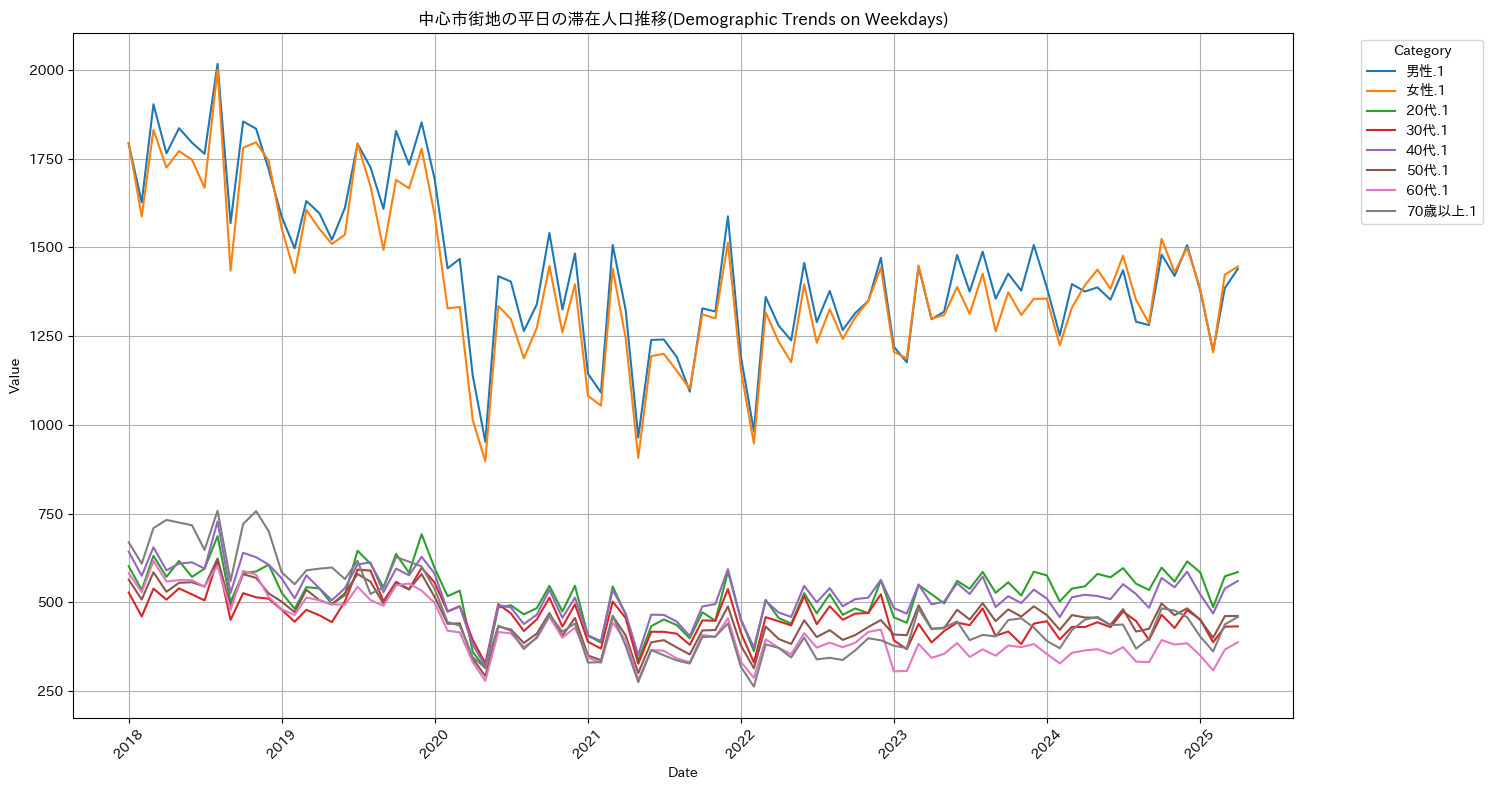

In [8]:

#グラフの描写
plt.figure(figsize=(15, 8))
sns.lineplot(data=center_weekday_melted, x='ds', y='Value', hue='Category')
plt.title('中心市街地の平日の滞在人口推移(Demographic Trends on Weekdays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### `center_holiday_df` 休日の場合

In [11]:
from numpy._core.defchararray import center
# 中心市街地の休日滞在人口データを抽出するための列名リストを作成
# 既存のdemographic_columns（['男性.1', '女性.1', ...]）のサフィックスを.1から.2に変更して、
# 休日のデータに対応するカラム名を作成します。
center_holiday_demographic_columns = [col.replace('.1', '.2') for col in demographic_columns]
center_holiday_demographic_columns

['男性.2', '女性.2', '20代.2', '30代.2', '40代.2', '50代.2', '60代.2', '70歳以上.2']

In [12]:
# center_dfからからdsカラムと、center_holiday_demographic_columnsを抽出
# 新しいdfを作成
center_holiday_df = center_df[['ds'] + center_holiday_demographic_columns].copy()

#平日と同様に、縦持ち形式（melt）に変換
center_holiday_melted = center_holiday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
center_holiday_melted['DAyType'] = 'Holiday'

# center_holiday_meltedのCategoryカラムから.1サフィックスを削除して、表示名を元のカテゴリ名に戻します。
center_holiday_melted['Category'] = center_holiday_melted['Category'].str.replace('.1', '', regex=False)
center_holiday_melted['Value'] = pd.to_numeric(center_holiday_melted['Value'])
center_holiday_melted

,ds,Category,Value,DAyType
0,2018-01-01,男性.2,741.6,Holiday
1,2018-02-01,男性.2,705.0,Holiday
2,2018-03-01,男性.2,832.1,Holiday
3,2018-04-01,男性.2,834.9,Holiday
4,2018-05-01,男性.2,846.1,Holiday
...,...,...,...,...
699,2024-12-01,70歳以上.2,167.9,Holiday
700,2025-01-01,70歳以上.2,169.5,Holiday
701,2025-02-01,70歳以上.2,178.8,Holiday
702,2025-03-01,70歳以上.2,208.0,Holiday


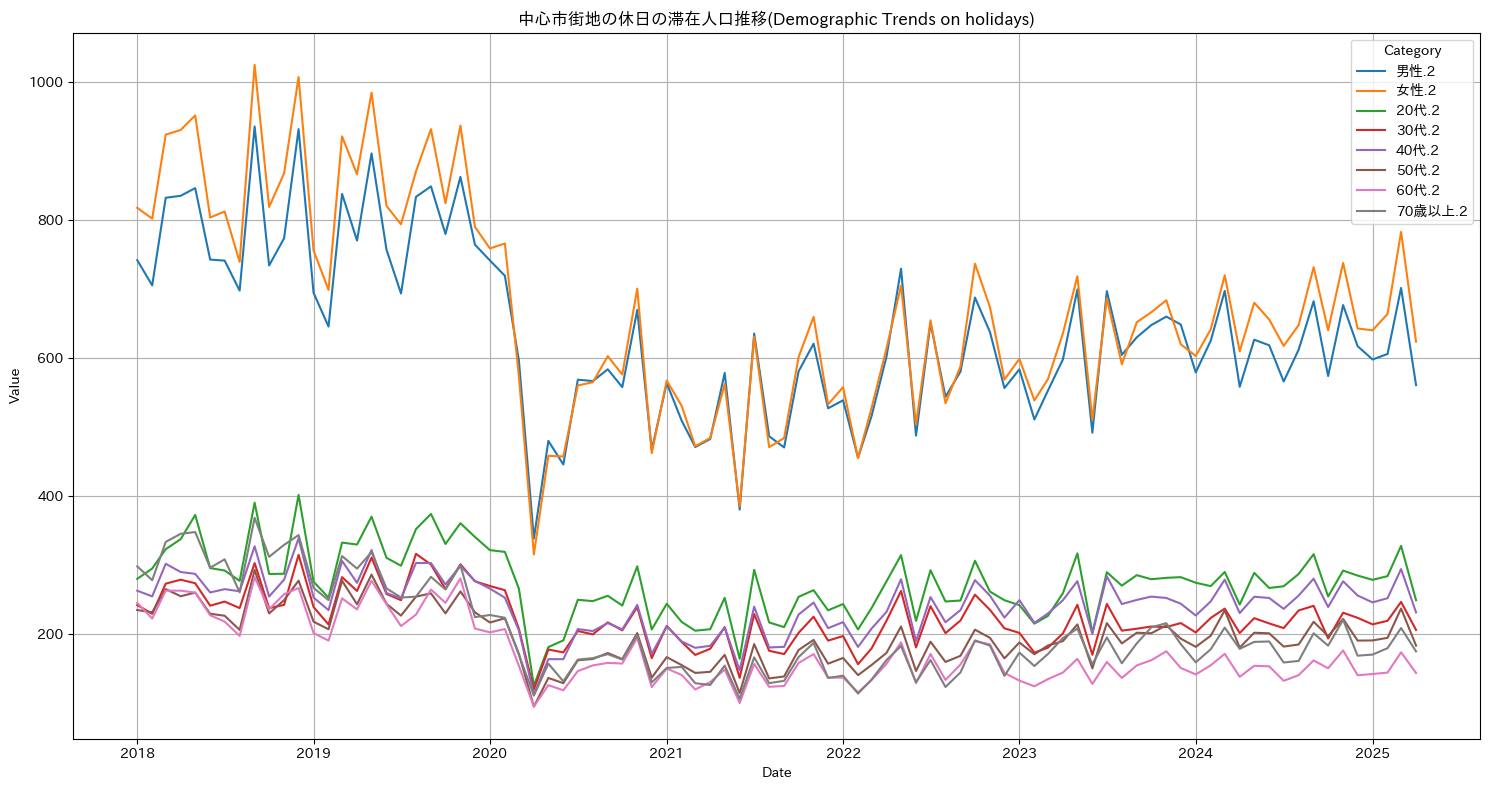

In [13]:
#中心市街地の休日滞在人口の推移を折れ線グラフでプロット
#center_holiday_meltedデータフレームを使用
plt.figure(figsize=(15, 8))
sns.lineplot(data=center_holiday_melted, x='ds', y='Value', hue='Category')
plt.title('中心市街地の休日の滞在人口推移(Demographic Trends on holidays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show()

### 予測結果①

### 中心市街地の季節性、トレンド分析

#### `center_weekday_df` 平日の場合

In [15]:
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
center_weekday_df['y'] = center_weekday_df['男性.1'] + center_weekday_df['女性.1']
center_weekday_df.head()

,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
0,2018-01-01,1791.2,1794.1,601.4,527.6,642.2,563.7,581.6,668.8,3585.3
1,2018-02-01,1626.6,1586.9,534.6,460.0,574.5,507.7,528.1,608.6,3213.5
2,2018-03-01,1903.0,1830.7,630.8,538.3,654.8,584.4,616.5,708.9,3733.7
3,2018-04-01,1764.6,1724.6,571.7,507.4,590.0,529.6,558.5,732.1,3489.2
4,2018-05-01,1835.4,1771.0,616.5,539.1,608.9,554.8,562.4,724.6,3606.4


In [16]:

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    center_weekday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

trend = result.trend
seasonal = result.seasonal
resid = result.resid

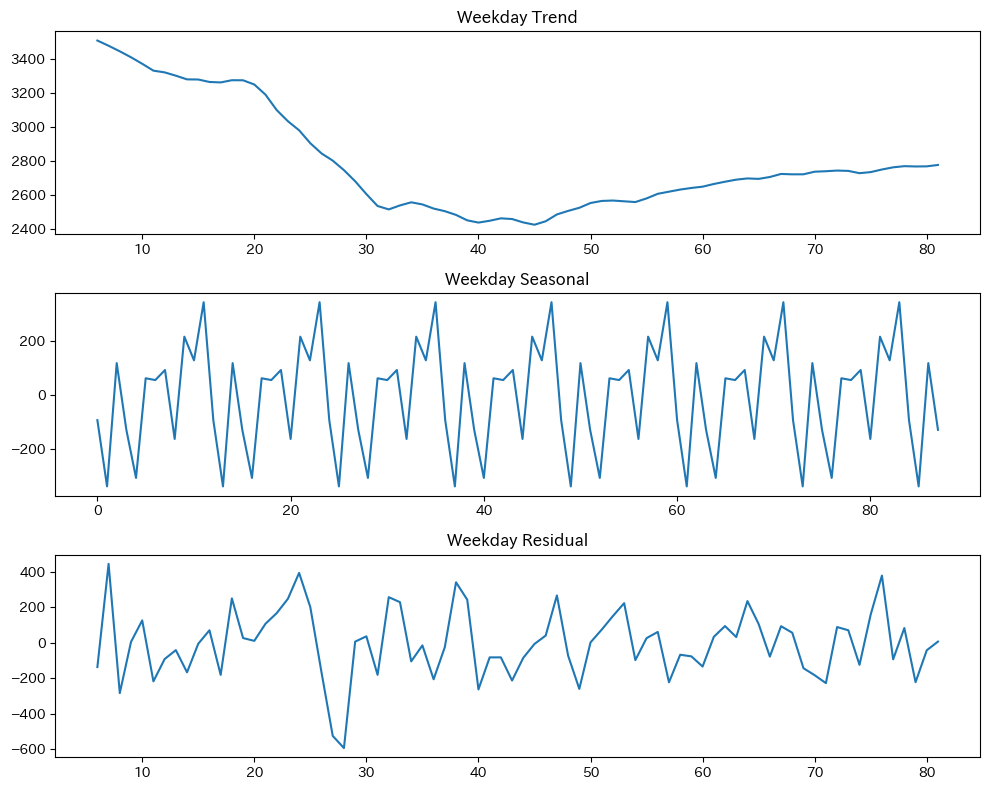

In [17]:

fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(trend)
axes[0].set_title('Weekday Trend')

# 季節成分のプロット
axes[1].plot(seasonal)
axes[1].set_title('Weekday Seasonal')

# 残差成分のプロット
axes[2].plot(resid)
axes[2].set_title('Weekday Residual')

plt.tight_layout()
plt.show()

#### `center_holiday_df` 休日の場合

In [18]:
center_holiday_df.head()

,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018-02-01,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018-03-01,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018-04-01,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018-05-01,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2


In [19]:
# 平日と同様に、休日
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
center_holiday_df['y'] = center_holiday_df['男性.2'] + center_holiday_df['女性.2']
center_holiday_df.head()

,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2,y
0,2018-01-01,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5,1559.1
1,2018-02-01,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4,1506.8
2,2018-03-01,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9,1755.7
3,2018-04-01,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7,1765.3
4,2018-05-01,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2,1797.6


In [20]:

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    center_holiday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

trend = result.trend
seasonal = result.seasonal
resid = result.resid

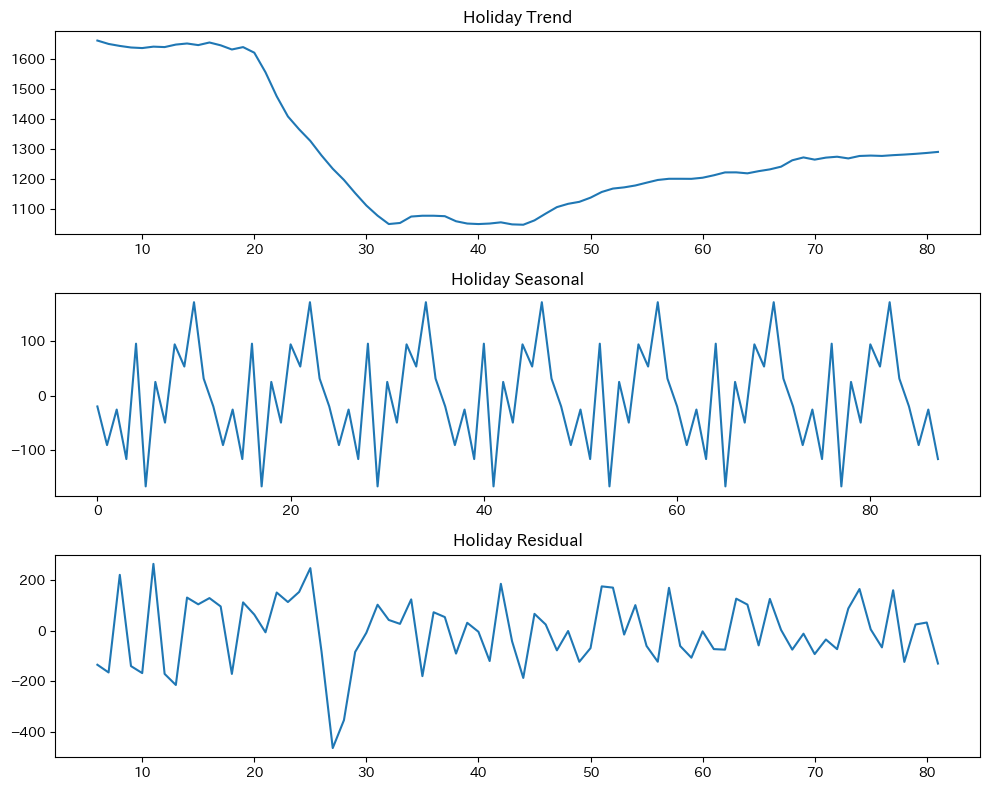

In [21]:

fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(trend)
axes[0].set_title('Holiday Trend')

# 季節成分のプロット
axes[1].plot(seasonal)
axes[1].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[2].plot(resid)
axes[2].set_title('Holiday Residual')

plt.tight_layout()
plt.show()

### 予測結果②

### 中心市街地のProphetモデル

In [22]:
#Prophetクラスをインポートし、インスタンス化
from prophet import Prophet
weekday_model = Prophet(seasonality_mode='multiplicative',interval_width=0.7)


#### `center_weekday_forecast` 平日の場合

In [23]:
#学習期間を2024年4月まで
weekday_model.fit(center_weekday_df[center_weekday_df['ds'] <= '2024-04-01'])

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [24]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
center_weekday_future = weekday_model.make_future_dataframe(periods=12, freq='MS')


In [25]:
#予測を実行
center_weekday_forecast = weekday_model.predict(center_weekday_future)

#出力された予測値や、不確実性区間を確認
center_weekday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,3515.100826,3327.545803,3711.356097
1,2018-02-01,3247.822315,3049.251006,3439.246328
2,2018-03-01,3757.858889,3552.047649,3952.890187
3,2018-04-01,3450.093855,3243.960386,3659.842002
4,2018-05-01,3245.173877,3038.766325,3440.147034
...,...,...,...,...
83,2024-12-01,3176.340455,2986.086482,3380.300386
84,2025-01-01,2500.274661,2310.352375,2695.767262
85,2025-02-01,2428.308211,2239.439360,2635.289708
86,2025-03-01,2916.459772,2714.669089,3130.931535


Text(0.5, 1.0, 'Center Weekday Forecast')

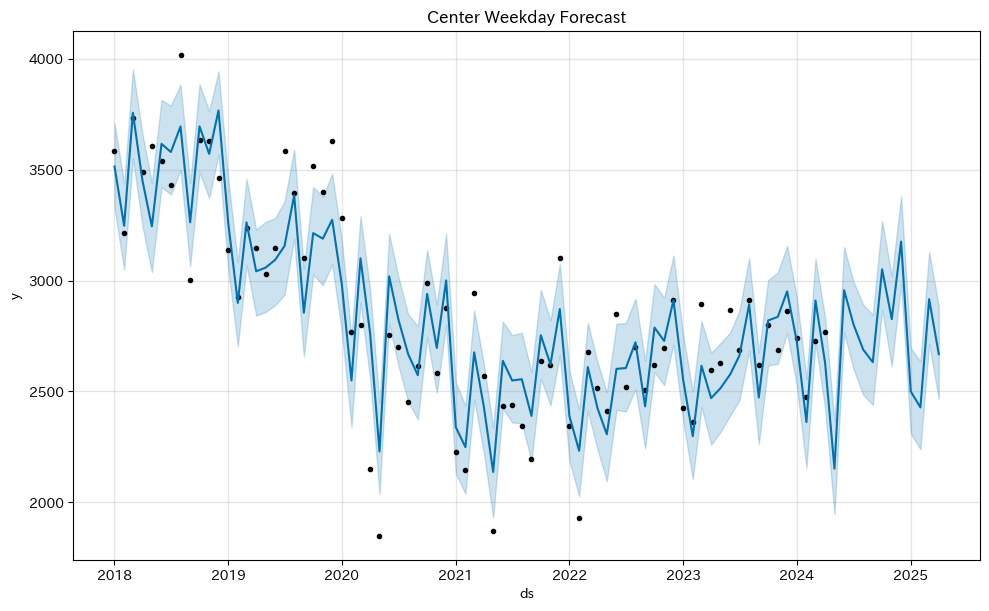

In [26]:
#グラフ上に可視化
fig_forecast = weekday_model.plot(center_weekday_forecast)
plt.title('Center Weekday Forecast')


In [28]:
#予測の評価
#cutoffsとして、4つの日付を持つデータを作成
cutoffs = pd.to_datetime(['2020-1', '2021-1', '2022-1', '2023-1'])

#cross_validation関数をインポートし、実行してテストパターンを作成
#引数には、cutoffsとhorizon（うるう年を考慮して366）を指定
from prophet.diagnostics import cross_validation
center_weekday_df_cv = cross_validation(weekday_model, horizon = '366 days', cutoffs=cutoffs)

  0%|          | 0/4 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.


In [29]:
#df_cvをもとに各評価指標を算出
#performance_metrics関数をインポートし、引数にdf_cvとmonthly=Trueを指定して実行
from prophet.diagnostics import performance_metrics
center_weekday_df_p = performance_metrics(center_weekday_df_cv, monthly=True)
center_weekday_df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1,6.837464e+04,261.485452,206.651532,0.082311,0.074382,0.080166,0.50
1,2,3.616211e+05,601.349398,583.501586,0.206674,0.183617,0.209956,0.00
2,3,4.485320e+05,669.725347,590.926011,0.251859,0.191842,0.236894,0.00
3,4,1.280931e+06,1131.782437,777.865655,0.391893,0.165580,0.290699,0.25
4,5,4.991421e+05,706.499890,612.425968,0.218683,0.240445,0.221797,0.25


Text(0.5, 1.0, 'mapeの推移')

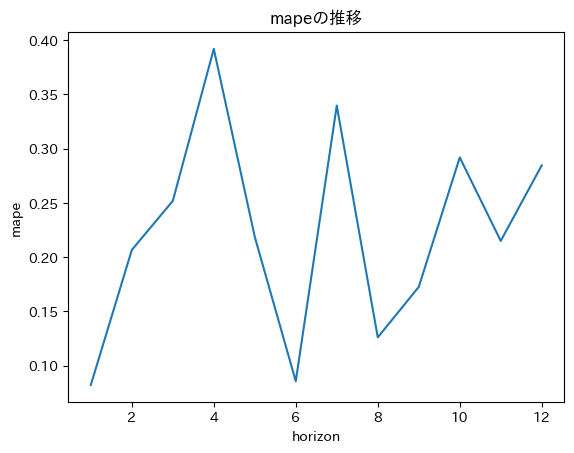

In [30]:
#mapeの推移を可視化
sns.lineplot(x='horizon', y='mape', data=center_weekday_df_p)
plt.title('mapeの推移')


Text(0.5, 1.0, 'coverageの推移')

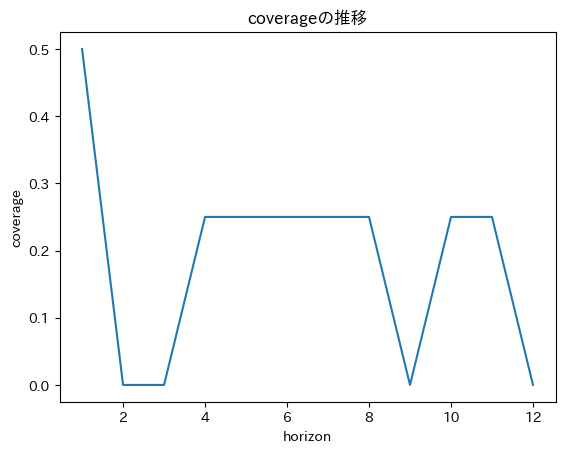

In [31]:
#不確実性区間に予測値が含まれている割合である、coverageの推移を確認
sns.lineplot(x='horizon', y='coverage', data=center_weekday_df_p)
plt.title('coverageの推移')


#### `center_holiday_forecast` 休日の場合

In [32]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
from prophet import Prophet
holiday_model = Prophet(seasonality_mode='multiplicative', interval_width=0.7)

#学習期間を2024年4月まで
holiday_model.fit(center_holiday_df[center_holiday_df['ds'] <= '2024-04-01'])


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [33]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
center_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [34]:
#予測を実行
center_holiday_forecast = holiday_model.predict(center_holiday_future)

#出力された予測値や、不確実性区間を確認
center_holiday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,1709.730233,1541.649154,1884.511646
1,2018-02-01,1622.328150,1467.951227,1793.075527
2,2018-03-01,1695.939299,1538.316400,1873.743579
3,2018-04-01,1629.724263,1462.059603,1811.840173
4,2018-05-01,1836.548440,1662.862969,2008.624909
...,...,...,...,...
83,2024-12-01,1173.350698,1006.386983,1332.483813
84,2025-01-01,1247.890162,1064.212134,1412.773303
85,2025-02-01,1207.146121,1048.481138,1364.246483
86,2025-03-01,1297.322712,1125.779735,1460.423920


Text(0.5, 1.0, 'Center Holiday Forecast')

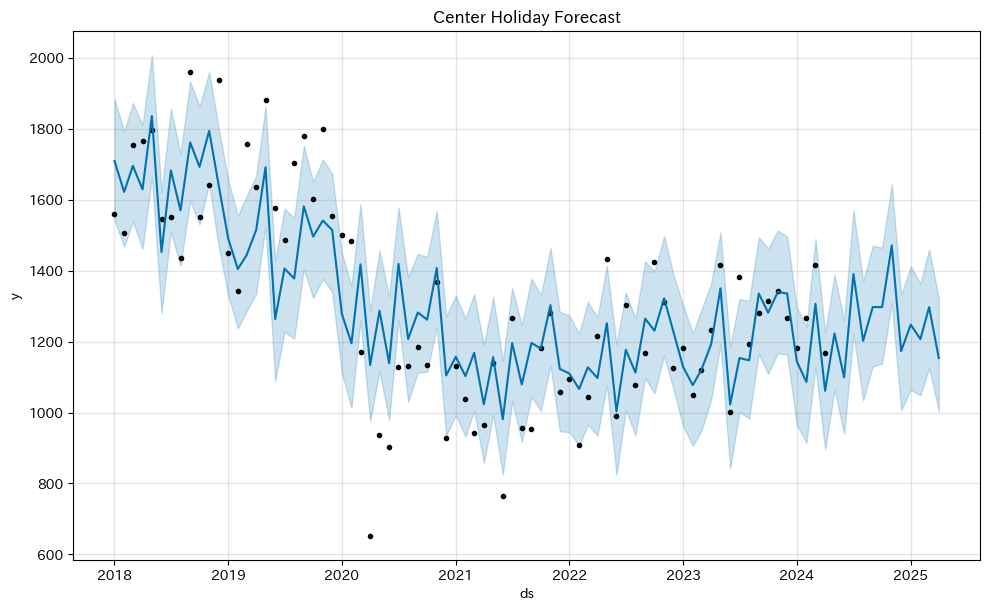

In [35]:
#グラフ上に可視化
fig_forecast = holiday_model.plot(center_holiday_forecast)
plt.title('Center Holiday Forecast')


In [36]:
#予測の評価
#cutoffsとして、4つの日付を持つデータを作成
cutoffs = pd.to_datetime(['2020-1', '2021-1', '2022-1', '2023-1'])

#cross_validation関数をインポートし、実行してテストパターンを作成
#引数には、cutoffsとhorizon（うるう年を考慮して366）を指定
from prophet.diagnostics import cross_validation
center_holiday_df_cv = cross_validation(holiday_model, horizon = '366 days', cutoffs=cutoffs)

  0%|          | 0/4 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.


In [37]:
#df_cvをもとに各評価指標を算出
#performance_metrics関数をインポートし、引数にdf_cvとmonthly=Trueを指定して実行
from prophet.diagnostics import performance_metrics
center_holiday_df_p = performance_metrics(center_holiday_df_cv, monthly=True)
center_holiday_df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1,20944.504384,144.722163,114.613990,0.095583,0.109974,0.102837,0.75
1,2,26006.438887,161.265120,161.088005,0.151423,0.153830,0.152914,0.75
2,3,395628.945261,628.990417,476.919230,0.602738,0.265730,0.417542,0.25
3,4,200550.678517,447.828850,406.067627,0.347275,0.303535,0.337769,0.25
4,5,112577.504891,335.525714,281.799676,0.308744,0.216370,0.277665,0.50


Text(0.5, 1.0, 'mapeの推移')

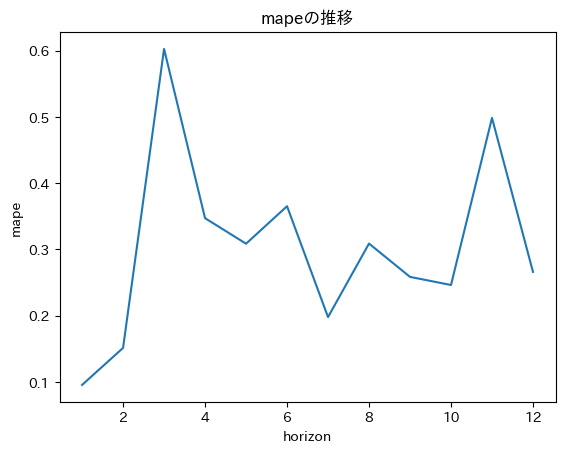

In [38]:
#mapeの推移を可視化
sns.lineplot(x='horizon', y='mape', data=center_holiday_df_p)
plt.title('mapeの推移')


Text(0.5, 1.0, 'coverageの推移')

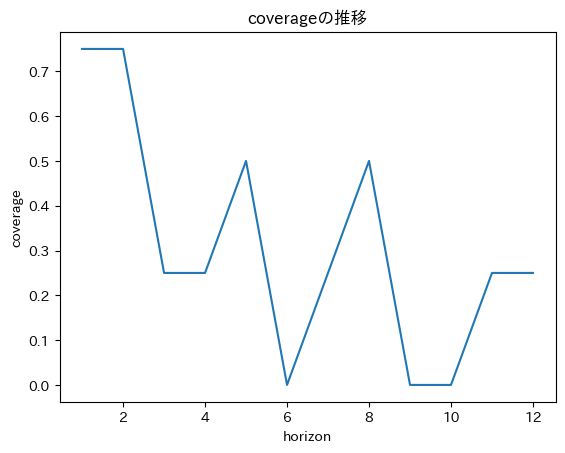

In [39]:
#不確実性区間に予測値が含まれている割合である、coverageの推移を確認
sns.lineplot(x='horizon', y='coverage', data=center_holiday_df_p)
plt.title('coverageの推移')


# 考察

## 傾向
～という傾向が見られる

##
～という仮説のもと、～という分析結果が得られて、以下のように考察します

##
～という分析結果から、～のようなことがわかりました。